In [1]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(scales)
library(patchwork)

Warning message:
“程辑包‘dplyr’是用R版本4.2.3 来建造的”

载入程辑包：‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“程辑包‘tidyr’是用R版本4.2.3 来建造的”


In [2]:
# 读入你刚刚导出的统计表
stat_df <- read.csv(
      "/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.2.cNMF_CD8T/4.3.2.CD8T_usage_immu_pheatmap/4.3.2.CD8T_cGEP_usage_cell_patient_stats.csv",
  stringsAsFactors = FALSE
)
# 先画病人的汇总热图。
# 只保留有 patient_auc 的
heat_df <- stat_df %>%
  select(dataset, cGEP, patient_N_R, patient_N_NR, patient_auc) %>%
  filter(!is.na(patient_auc))
colnames(heat_df)[2] = 'pathway'
colnames(heat_df)[3] = 'patient_R'
colnames(heat_df)[4] = 'patient_NR'

In [3]:
immudataInfo <- read.csv(
      "/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.2.cNMF_CD8T/4.3.2.CD8T_usage_immu_pheatmap/4.2.免疫治疗dataset.csv",
  stringsAsFactors = FALSE)
immudataInfo

Dataset,Cancer,Treatment,Celltype
<chr>,<chr>,<chr>,<chr>
BreastCancer_Lambrechts,BRCA,anti-PD-1,CD8T、Mono-Macro
GSE120575,SKCM,anti-PD-L1,CD8T、Mono-Macro
GSE123813,BCC,anti-PD-1,CD8T、NK、Mono-Macro
GSE123813,SCC,anti-PD-1,CD8T
GSE145281,BRCA,anti-PD-L1,CD8T、NK、Neutrophil
GSE169246,NSCLC,anti-PD-L1,CD8T、Mono-Macro
GSE200996,HNSCC,anti-PD-1&CTLA-4,CD8T、NK、Mono-Macro、Neutrophil
GSE203115,ESCC,anti-PD-1,CD8T、Mono-Macro、Neutrophil
GSE206325,ESCC,anti-PD-L1,CD8T、NK、Mono-Macro


In [4]:
# 排序
# 1.dataset 按名字
heat_df$dataset <- factor(
  heat_df$dataset,
  levels = unique(heat_df$dataset))

# 2. pathway , 1 到 70 的正确名称列表
levels_order <- paste0("cGEP", 1:70)

# 将 pathway 转换为因子，并指定 levels 顺序
heat_df$pathway <- factor(heat_df$pathway, levels = levels_order)

# --- 1. 数据过滤与准备 ---
# 过滤掉不需要的数据集
exclude_datasets <- c("RenalCarcinoma", "GSE203115","HCC_YeYouqiong","GSE123813_SCC","GSE123813_BCC","GSE145281")
heat_df_filt <- heat_df[!(heat_df$dataset %in% exclude_datasets), ]


In [5]:
library(dplyr)
immudataInfo <- read.csv(
      "/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.2.cNMF_CD8T/4.3.2.CD8T_usage_immu_pheatmap/4.2.免疫治疗dataset.csv",
  stringsAsFactors = FALSE)

# 1. 预处理 immudataInfo，生成对应的标签格式
# 格式为：Cancer_Dataset(Treatment)
info_mapping <- immudataInfo %>%
  mutate(new_label = paste0(Cancer, "_", Dataset, "(", Treatment, ")")) %>%
  select(Dataset, new_label)

# 2. 将新标签合并到 heat_df_filt 中
# 使用 left_join 根据 Dataset 进行匹配
heat_df_filt2 <- heat_df_filt %>%
  left_join(info_mapping, by = c("dataset" = "Dataset")) %>%
  mutate(dataset = ifelse(!is.na(new_label), new_label, dataset)) %>%
  select(-new_label) # 移除临时列


In [6]:
table(heat_df_filt2$dataset)


BRCA_BreastCancer_Lambrechts(anti-PD-1)              ESCC_GSE206325(anti-PD-L1) 
                                     70                                      70 
         GC_GSE232240(anti-PD-1&CTLA-4)       HNSCC_GSE200996(anti-PD-1&CTLA-4) 
                                     70                                      70 
      HNSCC_Lambrechts_HNSCC(anti-PD-1)               LUAD_GSE229353(anti-PD-1) 
                                     70                                      70 
            NSCLC_GSE169246(anti-PD-L1)              NSCLC_GSE207422(anti-PD-1) 
                                     70                                      70 
             SKCM_GSE120575(anti-PD-L1)               TNBC_GSE246613(anti-PD-1) 
                                     70                                      70 

In [7]:
CD8T_cGEP <- read.csv("/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.2.cNMF_CD8T/3.cGEP_topgene/3.3.CD8T_cGEP_Anno_Complete_With_Genes.csv",
  stringsAsFactors = FALSE,
  check.names = FALSE)
CD8T_cGEP$cGEP_Cluster <- factor(CD8T_cGEP$cGEP_Cluster, levels = paste0("cGEP", 1:70))
CD8T_cGEP$Display_Label <- paste0(CD8T_cGEP$cGEP_Cluster, ": ", CD8T_cGEP$cGEP_Anno_Name)
CD8T_cGEP <- CD8T_cGEP[order(CD8T_cGEP$cGEP_Cluster), ]

In [8]:
library(dplyr)
library(ggplot2)
library(patchwork)

# =========================================================
# 函数：绘制 CD8T_cGEP cGEP 热图 + 可选注释条过滤
# =========================================================
plot_CD8T_heatmap <- function(
  heat_df,           # 主热图数据框，列：dataset, pathway, patient_auc
  anno_df,           # 注释数据框，列：cGEP_Cluster, cGEP_Anno_Name, Category
  keep_categories,   # 需要保留的 Category 向量，例如 c("Function","Artifact")
  output_file,       # 保存 PDF 路径
  width = 12,
  height = 16,
  fill_midpoint = 0.6
) {
  
  # ---------------------------
  # 1️⃣ 排序 cGEP
  # ---------------------------
  sorted_cgeps <- heat_df %>%
    group_by(pathway) %>%
    summarise(mean_auc = mean(patient_auc, na.rm = TRUE)) %>%
    arrange(mean_auc) %>%
    pull(pathway)
  
  # ---------------------------
  # 2️⃣ 主热图 factor
  # ---------------------------
  heat_df$pathway <- factor(heat_df$pathway, levels = sorted_cgeps)
  
  # ---------------------------
  # 3️⃣ 注释条 factor & 过滤
  # ---------------------------
  # 关键修改：只保留热图中存在的cGEP_Cluster
  anno_df <- anno_df %>%
    filter(cGEP_Cluster %in% sorted_cgeps) %>%  # 先过滤热图中存在的Cluster
    filter(Category %in% keep_categories) %>%   # 再过滤需要的类别
    arrange(match(cGEP_Cluster, sorted_cgeps))  # 按照热图顺序排序
  
  # 更新sorted_cgeps，只包含注释条中存在的
  sorted_cgeps_filtered <- intersect(sorted_cgeps, unique(anno_df$cGEP_Cluster))
  
  # 设置因子水平（使用过滤后的顺序）
  anno_df$cGEP_Cluster <- factor(anno_df$cGEP_Cluster, levels = sorted_cgeps_filtered)
  
  # labels 对齐
  anno_labels <- anno_df$cGEP_Anno_Name
  names(anno_labels) <- anno_df$cGEP_Cluster
  
  # ---------------------------
  # 4️⃣ 主热图（需要过滤以匹配注释条）
  # ---------------------------
  # 如果注释条过滤后为空，则不绘制注释条
  if (nrow(anno_df) == 0) {
    warning("过滤后注释条为空，将只绘制热图")
    heat_df_filtered <- heat_df
  } else {
    # 只保留注释条中存在的pathway
    heat_df_filtered <- heat_df %>%
      filter(pathway %in% sorted_cgeps_filtered)
    
    # 重新设置因子水平以匹配注释条顺序
    heat_df_filtered$pathway <- factor(heat_df_filtered$pathway, levels = sorted_cgeps_filtered)
  }
  
  p_main <- ggplot(
    heat_df_filtered,
    aes(x = dataset, y = pathway, fill = patient_auc)
  ) +
    geom_tile(color = "white", linewidth = 0.2) +
    scale_fill_gradient2(
      low = "#2166AC", mid = "white", high = "#B2182B",
      midpoint = fill_midpoint, name = "AUC"
    ) +
    scale_x_discrete(expand = c(0, 0)) +
    scale_y_discrete(expand = c(0, 0)) +
    theme_minimal() +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 15, color = "black",face = "bold.italic"),
      axis.text.y = element_text(size = 13, color = "black",face = "bold.italic"),
      panel.grid = element_blank(),
      axis.title = element_blank(),
      legend.position = "left",
      # margin 的四个参数分别是：上 (t), 右 (r), 下 (b), 左 (l)
      # 因为你的标签向左下角伸出，所以需要大幅增加 b 和 
      plot.margin = margin(t = 10, r = 0, b = 120, l = 150, unit = "pt")
    )
  
  # ---------------------------
  # 5️⃣ 注释条（仅在存在数据时绘制）
  # ---------------------------
  if (nrow(anno_df) > 0) {
    fill_values <- setNames(
      c("#4daf4a", "#999999", "#377eb8", "#984ea3")[match(keep_categories, c("Functional","Artifact","Lineage","Doublet"))],
      keep_categories
    )
    
    p_side <- ggplot(
      anno_df,
      aes(x = "Class", y = cGEP_Cluster, fill = Category)
    ) +
      geom_tile(color = "white", linewidth = 0.2) +
      scale_fill_manual(values = fill_values, name = "Class") +
      scale_x_discrete(expand = c(0, 0)) +
      scale_y_discrete(
        expand = c(0, 0), 
        position = "right", 
        labels = anno_labels,
        limits = levels(anno_df$cGEP_Cluster)  # 确保与热图y轴完全一致
      ) +
      theme_minimal() +
      theme(
        axis.text.x = element_text(angle = 90, vjust = 0.5, size = 15, face = "bold.italic", color = "black"),
        axis.text.y = element_text(size = 15, color = "black",hjust = 0,face = "bold.italic",),
        panel.grid = element_blank(),
        axis.title = element_blank(),
        plot.margin = margin(t = 10, r = 100, b = 60, l = 0, unit = "pt")
      )
    
    # ---------------------------
    # 6️⃣ 拼接 + 保存
    # ---------------------------
    final_plot <- (p_main | p_side) +
      plot_layout(widths = c(5, 0.3), guides = "collect") &
      theme(panel.spacing = unit(0, "pt"))
  } else {
    # 如果注释条为空，只绘制热图
    final_plot <- p_main
  }
  
  ggsave(output_file, final_plot, width = width, height = height, limitsize = FALSE)
  
  return(final_plot)
}

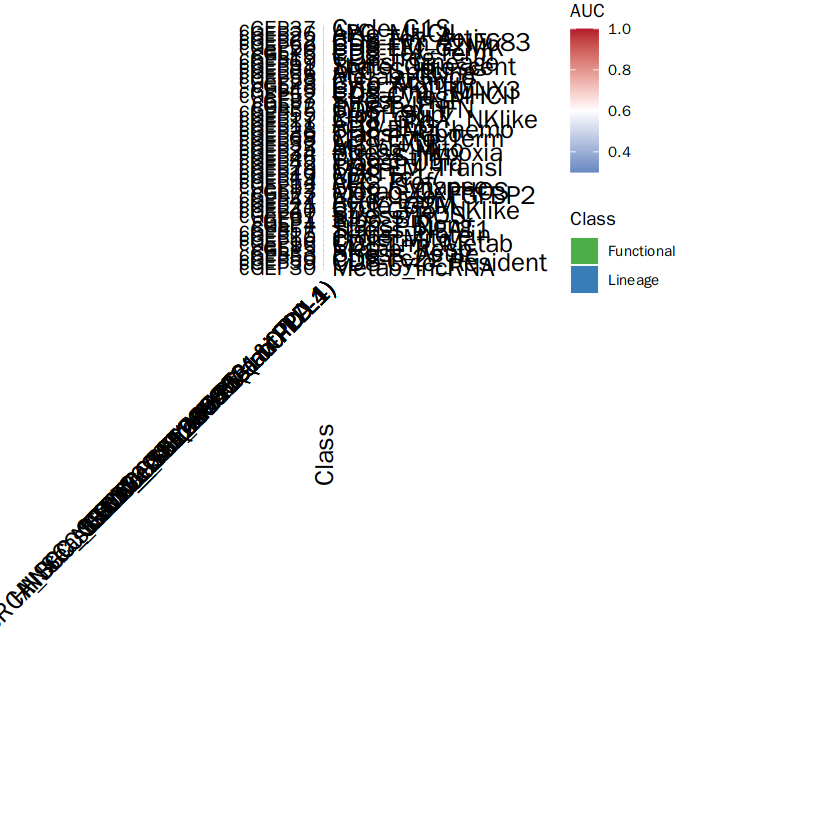

In [9]:
# 只保留 Function 和 Artifact
plot_CD8T_heatmap(
  heat_df = heat_df_filt2,
  anno_df = CD8T_cGEP,
  keep_categories = c("Functional","Lineage"),
  output_file = "./4.3.2.CD8T_usage_immu_pheatmap/4.3.3.CD8T_GEP70_usage_paper_.pdf",
  width = 12,
  height = 16
)


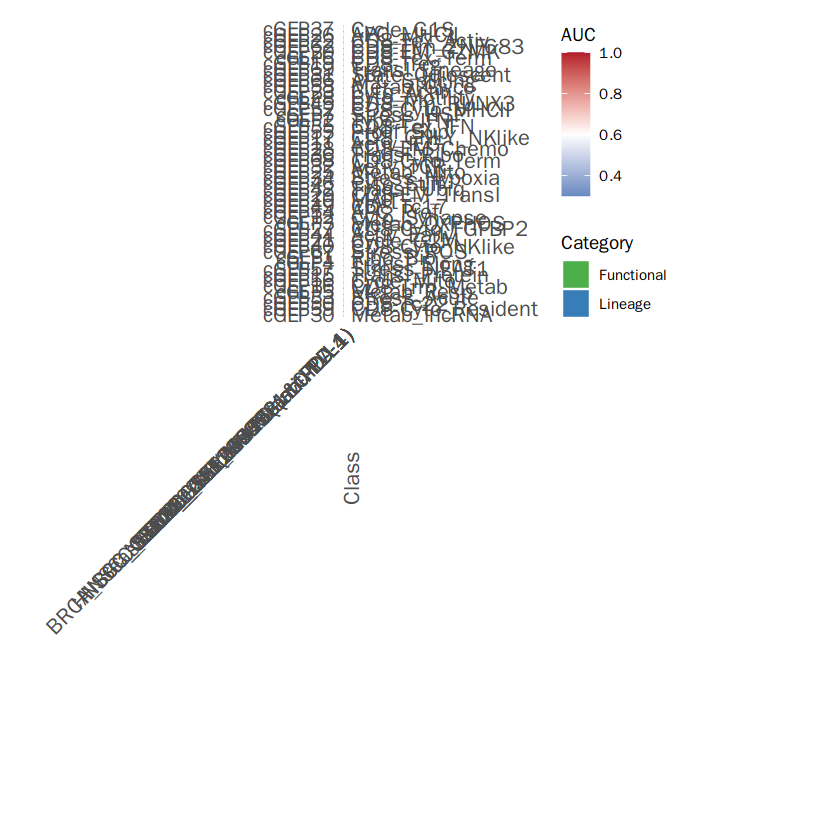

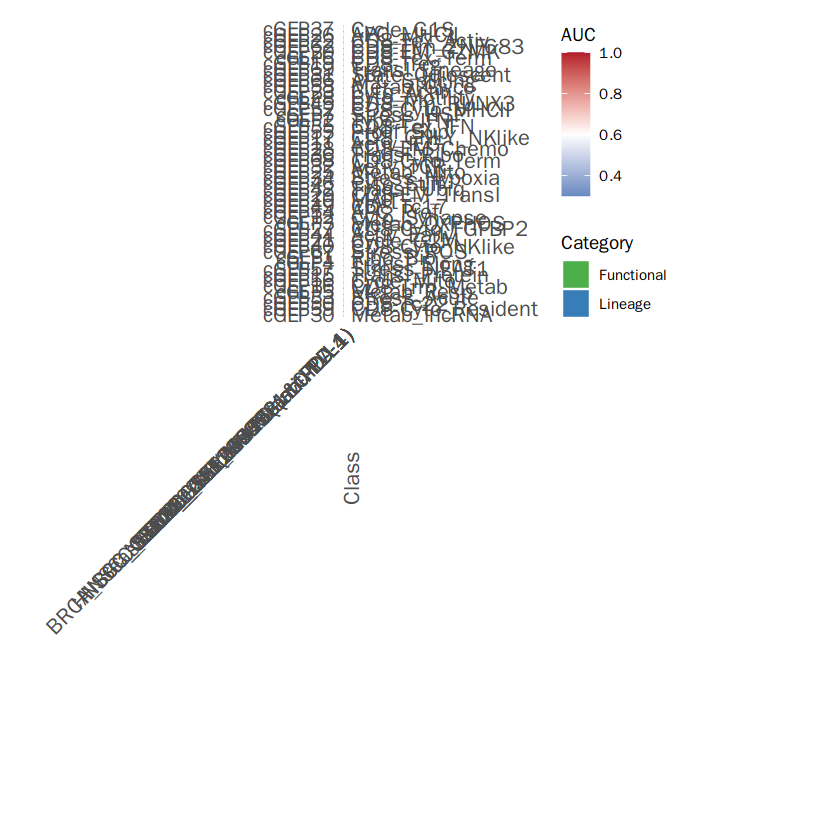

In [10]:
library(dplyr)
library(ggplot2)
library(patchwork)

plot_heatmap <- function(
  heat_df,
  anno_df,
  keep_categories,
  output_file,
  cell_width,
  cell_height,
  fill_midpoint = 0.6
){

  # 1️⃣ 排序
  sorted_cgeps <- heat_df %>%
    group_by(pathway) %>%
    summarise(mean_auc = mean(patient_auc, na.rm = TRUE)) %>%
    arrange(mean_auc) %>%
    pull(pathway)

  heat_df$pathway <- factor(heat_df$pathway, levels = sorted_cgeps)

  # 2️⃣ annotation过滤
  anno_df <- anno_df %>%
    filter(cGEP_Cluster %in% sorted_cgeps) %>%
    filter(Category %in% keep_categories) %>%
    arrange(match(cGEP_Cluster, sorted_cgeps))

  sorted_cgeps_filtered <- intersect(sorted_cgeps, unique(anno_df$cGEP_Cluster))

  anno_df$cGEP_Cluster <- factor(
    anno_df$cGEP_Cluster,
    levels = sorted_cgeps_filtered
  )

  anno_labels <- anno_df$cGEP_Anno_Name
  names(anno_labels) <- anno_df$cGEP_Cluster

  heat_df_filtered <- heat_df %>%
    filter(pathway %in% sorted_cgeps_filtered)

  heat_df_filtered$pathway <- factor(
    heat_df_filtered$pathway,
    levels = sorted_cgeps_filtered
  )

  # 3️⃣ 自动计算图尺寸
  n_row <- length(sorted_cgeps_filtered)
  n_col <- length(unique(heat_df_filtered$dataset))

  height <- n_row * cell_height + 4
  width  <- n_col * cell_width + 8

  # 4️⃣ 主热图
  p_main <- ggplot(
    heat_df_filtered,
    aes(dataset, pathway, fill = patient_auc)
  ) +
    geom_tile(color="white", linewidth=0.3) +
    scale_fill_gradient2(
      low="#2166AC",
      mid="white",
      high="#B2182B",
      midpoint=fill_midpoint,
      name="AUC"
    ) +
    scale_x_discrete(expand=c(0,0)) +
    scale_y_discrete(expand=c(0,0)) +
    theme_minimal() +
    theme(
      axis.text.x = element_text(
        angle=45,
        hjust=1,
        size=13,
        face="bold"
      ),
      axis.text.y = element_text(
        size=12,
        face="bold"
      ),
      panel.grid = element_blank(),
      axis.title = element_blank(),
      legend.position = "left",
      plot.margin = margin(10,0,120,160)
    )

  # 5️⃣ annotation
  fill_values <- setNames(
    c("#4daf4a","#377eb8","#999999","#984ea3")[
      match(keep_categories,
      c("Functional","Lineage","Artifact","Doublet"))
    ],
    keep_categories
  )

  p_side <- ggplot(
    anno_df,
    aes("Class", cGEP_Cluster, fill = Category)
  ) +
    geom_tile(color="white", linewidth=0.3) +
    scale_fill_manual(values = fill_values) +
    scale_x_discrete(expand=c(0,0)) +
    scale_y_discrete(
      expand=c(0,0),
      position="right",
      labels=anno_labels
    ) +
    theme_minimal() +
    theme(
      axis.text.x = element_text(
        angle=90,
        size=13,
        face="bold"
      ),
      axis.text.y = element_text(
        size=13,
        face="bold",
        hjust=0
      ),
      panel.grid = element_blank(),
      axis.title = element_blank(),
      plot.margin = margin(10,100,40,0)
    )

  # 6️⃣ 拼接
  final_plot <- (p_main | p_side) +
    plot_layout(widths=c(5,0.35), guides="collect") &
    theme(panel.spacing = unit(0,"pt"))

  # 7️⃣ 保存
  ggsave(
    output_file,
    final_plot,
    width = width,
    height = height,
    dpi = 300,
    limitsize = FALSE
  )

  return(final_plot)
}
# 只保留 Function 和 Artifact
plot_heatmap(
  heat_df = heat_df_filt2,
  anno_df = CD8T_cGEP,
  keep_categories = c("Functional","Lineage"),
  output_file = "./4.3.2.CD8T_usage_immu_pheatmap/4.3.3.CD8T_GEP70_usage_paper-v0417.png",
  cell_width = 0.5,
  cell_height = 0.25
)
plot_heatmap(
  heat_df = heat_df_filt2,
  anno_df = CD8T_cGEP,
  keep_categories = c("Functional","Lineage"),
  output_file = "./4.3.2.CD8T_usage_immu_pheatmap/4.3.3.CD8T_GEP70_usage_paper-v0417.pdf",
  cell_width = 0.5,
  cell_height = 0.25
)

In [12]:
sorted_cgeps

ERROR: Error: 找不到对象'sorted_cgeps'


In [ ]:
# 修改轴，加上癌肿名称和治疗方法